In [ ]:
# GTZAN Dataset Exploratory Data Analysis

## Objective

Explore the GTZAN music dataset before feature extraction and
classical machine-learning experiments.

We investigate:
- Genre distribution
- Track counts
- Audio properties
- Dataset validity
- Song-level train/validation/test split

In [2]:
import sys
print(sys.executable)

x:\prep_placements\ML mini proj\music-genre-classification\.venv\Scripts\python.exe


In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import librosa
import matplotlib.pyplot as plt

print("ALL IMPORTS OK")

ALL IMPORTS OK


In [3]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
MANIFEST_PATH = PROJECT_ROOT / "data" / "split_manifest.csv"

print("Project root:", PROJECT_ROOT)
print("Manifest path:", MANIFEST_PATH)
print("Manifest exists:", MANIFEST_PATH.exists())

Project root: x:\prep_placements\ML mini proj\music-genre-classification
Manifest path: x:\prep_placements\ML mini proj\music-genre-classification\data\split_manifest.csv
Manifest exists: True


In [4]:
df = pd.read_csv(MANIFEST_PATH)

print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

df.head()


Number of rows: 1000
Number of columns: 3


,relative_path,genre,split
0,genres/blues/blues.00001.au,blues,test
1,genres/blues/blues.00021.au,blues,test
2,genres/blues/blues.00029.au,blues,test
3,genres/blues/blues.00032.au,blues,test
4,genres/blues/blues.00037.au,blues,test


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   relative_path  1000 non-null   str  
 1   genre          1000 non-null   str  
 2   split          1000 non-null   str  
dtypes: str(3)
memory usage: 23.6 KB


In [6]:
df.columns.tolist()

['relative_path', 'genre', 'split']

In [7]:
df.head(10)

,relative_path,genre,split
0,genres/blues/blues.00001.au,blues,test
1,genres/blues/blues.00021.au,blues,test
2,genres/blues/blues.00029.au,blues,test
3,genres/blues/blues.00032.au,blues,test
4,genres/blues/blues.00037.au,blues,test
5,genres/blues/blues.00051.au,blues,test
6,genres/blues/blues.00052.au,blues,test
7,genres/blues/blues.00057.au,blues,test
8,genres/blues/blues.00058.au,blues,test
9,genres/blues/blues.00059.au,blues,test


In [8]:
print("Number of genres:", df["genre"].nunique())

print("\nGenres:")
print(sorted(df["genre"].unique()))

print("\nTracks per genre:")
print(df["genre"].value_counts().sort_index())

print("\nSplit distribution:")
print(df["split"].value_counts())

print("\nSplit distribution by genre:")
print(pd.crosstab(df["genre"], df["split"]))

print("\nDuplicate relative paths:")
print(df["relative_path"].duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum())

Number of genres: 10

Genres:
['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

Tracks per genre:
genre
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100
Name: count, dtype: int64

Split distribution:
split
train         700
test          150
validation    150
Name: count, dtype: int64

Split distribution by genre:
split      test  train  validation
genre                             
blues        15     70          15
classical    15     70          15
country      15     70          15
disco        15     70          15
hiphop       15     70          15
jazz         15     70          15
metal        15     70          15
pop          15     70          15
reggae       15     70          15
rock         15     70          15

Duplicate relative paths:
0

Missing values:
relative_path    0
genre            0
split        

In [9]:
split_per_track = df.groupby("relative_path")["split"].nunique()

leaky_tracks = split_per_track[split_per_track > 1]

print("Tracks appearing in multiple splits:", len(leaky_tracks))

Tracks appearing in multiple splits: 0


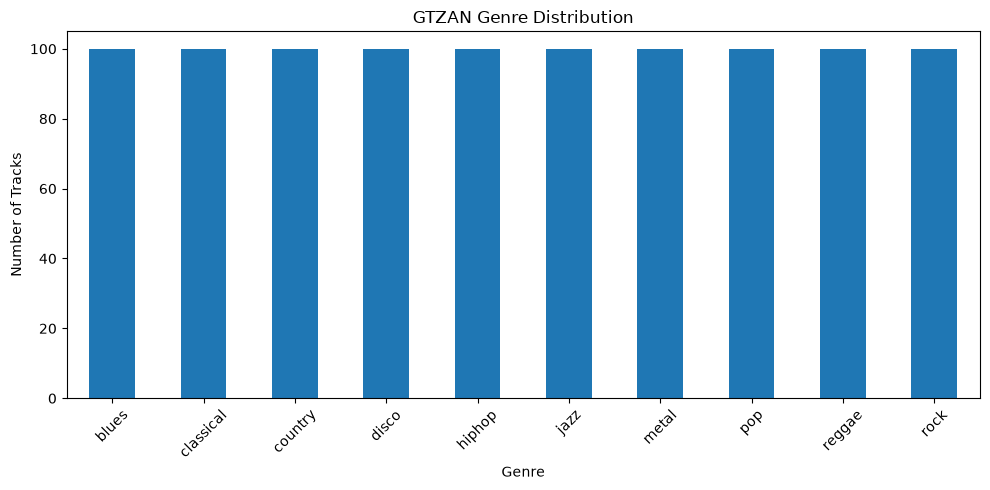

In [10]:
genre_counts = df["genre"].value_counts().sort_index()

plt.figure(figsize=(10, 5))

genre_counts.plot(kind="bar")

plt.title("GTZAN Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Number of Tracks")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

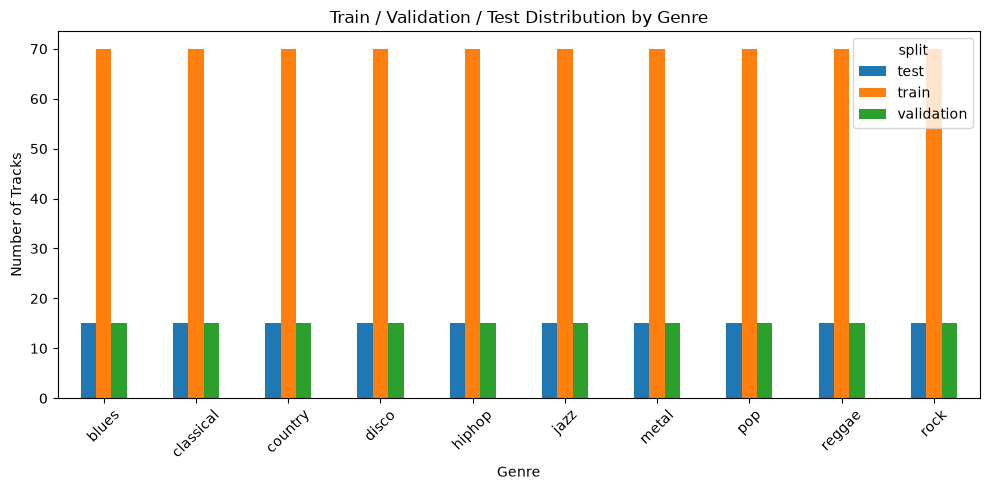

In [11]:
split_counts = pd.crosstab(df["genre"], df["split"])

split_counts.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Train / Validation / Test Distribution by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Tracks")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [13]:
split_per_track = df.groupby("relative_path")["split"].nunique()

print(
    "Tracks appearing in multiple splits:",
    (split_per_track > 1).sum()
)

Tracks appearing in multiple splits: 0
